# 02 — Feature Engineering
**BOVA11 ML Pipeline**

Objetivo: construir o dataset de features técnicas que alimentarão os modelos de classificação.

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

In [2]:
raw = pd.read_parquet('../data/processed/bova11_eda.parquet')
df  = raw[['open','high','low','close','volume','retorno']].copy()
print(f'Dados carregados: {df.shape}')

Dados carregados: (2459, 6)


## 1. Target — direção do retorno D+1

In [3]:
# 1 = alta, 0 = queda no próximo dia
df['target'] = (df['retorno'].shift(-1) > 0).astype(int)

print('Distribuição do target:')
print(df['target'].value_counts(normalize=True).rename({1: 'Alta (1)', 0: 'Queda (0)'})
      .apply(lambda x: f'{x:.2%}'))

Distribuição do target:
target
Alta (1)     52.42%
Queda (0)    47.58%
Name: proportion, dtype: object


## 2. Indicadores de momentum

In [4]:
def rsi(serie, periodo=14):
    delta = serie.diff()
    ganho = delta.clip(lower=0).ewm(span=periodo).mean()
    perda = (-delta.clip(upper=0)).ewm(span=periodo).mean()
    rs    = ganho / perda
    return 100 - (100 / (1 + rs))

# RSI
df['rsi_14'] = rsi(df['close'], 14)
df['rsi_7']  = rsi(df['close'], 7)

# MACD
ema12 = df['close'].ewm(span=12).mean()
ema26 = df['close'].ewm(span=26).mean()
df['macd']        = ema12 - ema26
df['macd_signal'] = df['macd'].ewm(span=9).mean()
df['macd_hist']   = df['macd'] - df['macd_signal']

# Retornos em múltiplas janelas
for janela in [1, 2, 5, 10, 21]:
    df[f'ret_{janela}d'] = df['close'].pct_change(janela)

print('Indicadores de momentum calculados.')
df[['rsi_14', 'macd', 'macd_hist', 'ret_5d']].tail(3)

Indicadores de momentum calculados.


,rsi_14,macd,macd_hist,ret_5d
Date,,,,
2024-12-26,34.983632,-1.798146,-0.456540,-0.029934
2024-12-27,32.324809,-1.897873,-0.445014,-0.007113
2024-12-30,32.409439,-1.953582,-0.400578,-0.006018


## 3. Volatilidade e bandas de Bollinger

In [5]:
# Bollinger Bands (20, 2σ)
for janela in [20, 50]:
    sma  = df['close'].rolling(janela).mean()
    std  = df['close'].rolling(janela).std()
    upper = sma + 2 * std
    lower = sma - 2 * std
    df[f'bb_pos_{janela}']   = (df['close'] - lower) / (upper - lower)   # 0=banda inf, 1=banda sup
    df[f'bb_width_{janela}'] = (upper - lower) / sma                      # largura relativa

# ATR (Average True Range)
high_low  = df['high'] - df['low']
high_prev = (df['high'] - df['close'].shift()).abs()
low_prev  = (df['low']  - df['close'].shift()).abs()
tr = pd.concat([high_low, high_prev, low_prev], axis=1).max(axis=1)
df['atr_14'] = tr.rolling(14).mean() / df['close']  # normalizado pelo preço

# Volatilidade rolling
for janela in [5, 21, 63]:
    df[f'vol_{janela}d'] = df['retorno'].rolling(janela).std() * np.sqrt(252)

print('Volatilidade e Bollinger Bands calculados.')

Volatilidade e Bollinger Bands calculados.


## 4. Tendência e médias móveis

In [6]:
# Distância relativa das médias móveis
for janela in [20, 50, 200]:
    sma = df['close'].rolling(janela).mean()
    df[f'dist_sma_{janela}'] = (df['close'] - sma) / sma

# Slope da SMA50 (taxa de mudança)
sma50 = df['close'].rolling(50).mean()
df['slope_sma50'] = sma50.pct_change(5)

# Cruzamento de médias (golden/death cross)
sma20  = df['close'].rolling(20).mean()
sma200 = df['close'].rolling(200).mean()
df['cross_20_200'] = (sma20 > sma200).astype(int)

print('Tendência calculada.')

Tendência calculada.


## 5. Features de volume

In [7]:
# OBV (On Balance Volume)
obv = (np.sign(df['retorno']) * df['volume']).cumsum()
df['obv_norm'] = (obv - obv.rolling(20).mean()) / obv.rolling(20).std()

# Volume relativo (vs média 20 dias)
df['vol_rel'] = df['volume'] / df['volume'].rolling(20).mean()

# Tendência de volume
df['vol_trend'] = df['volume'].rolling(5).mean() / df['volume'].rolling(20).mean()

print('Features de volume calculadas.')

Features de volume calculadas.


## 6. Features temporais

In [8]:
df['dia_semana'] = df.index.dayofweek
df['mes']        = df.index.month
df['trimestre']  = df.index.quarter

# Efeito segunda-feira e sexta-feira
df['is_segunda'] = (df['dia_semana'] == 0).astype(int)
df['is_sexta']   = (df['dia_semana'] == 4).astype(int)

## 7. Matriz de correlação das features com o target

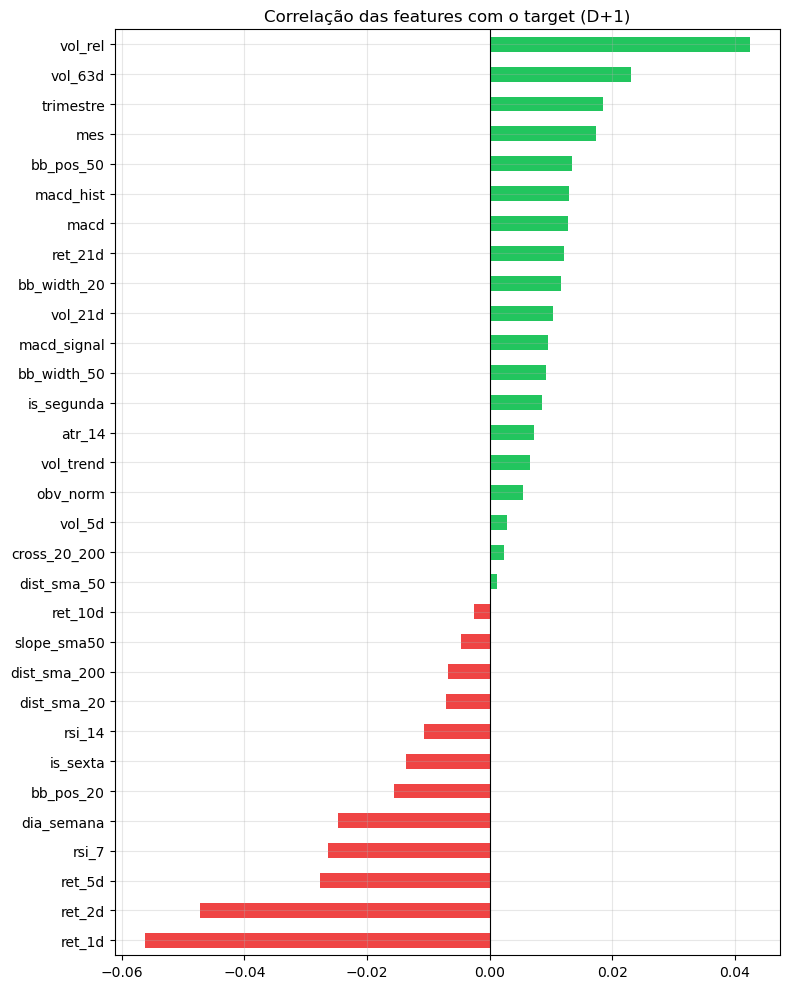

In [9]:
feature_cols = [c for c in df.columns if c not in 
                ['open','high','low','close','volume','retorno','target']]

correlacoes = df[feature_cols + ['target']].corr()['target'].drop('target').sort_values()

fig, ax = plt.subplots(figsize=(8, 10))
colors = ['#ef4444' if v < 0 else '#22c55e' for v in correlacoes]
correlacoes.plot(kind='barh', ax=ax, color=colors)
ax.set_title('Correlação das features com o target (D+1)')
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('../data/processed/correlacao_features.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Salvar dataset final

In [10]:
# Remove NaNs gerados pelas janelas rolantes
df_final = df.dropna()

# Separa features e target
X = df_final[feature_cols]
y = df_final['target']

df_final.to_parquet('../data/processed/bova11_features.parquet')

print(f'Dataset final salvo:')
print(f'  Linhas:    {df_final.shape[0]}')
print(f'  Features:  {len(feature_cols)}')
print(f'  Target 1:  {y.mean():.2%} (positivo)')
print(f'  Target 0:  {(1-y).mean():.2%} (negativo)')
print('\nPróximo passo → 03_model.ipynb')

Dataset final salvo:
  Linhas:    2260
  Features:  31
  Target 1:  52.74% (positivo)
  Target 0:  47.26% (negativo)

Próximo passo → 03_model.ipynb
